In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [12]:
df1 = pd.read_csv("data/analyse_cuts_test1_no_norm.csv")
df2 = pd.read_csv("data/analyse_cuts_test1_norm.csv")


In [13]:
def normalize(data):
    min = np.min(data)
    factor = np.max(data)-np.min(data)
    norm_data = (data - min)/factor
    print(f"factor: {factor} - min: {min}")
    return norm_data

def fit_to(org, data):
    
    org_fac = np.max(org) - np.min(org)
    data_fac = np.max(data) - np.min(data)
    factor = org_fac / data_fac
    data = data*factor
    
    
    org_min = np.min(org)
    data_min = np.min(data)
    shift = org_min - data_min
    data = data + shift
    
    print(f"shift: {shift} - factor: {factor}")
    return data
    
    
params = df1.columns
params = [p for p in params if p not in ['Unnamed: 0','start_index', 'end_index', 'timediff',"m", 'bedingung', 'bedingung2', 'final']]
params

['std_prev',
 'std_next',
 'mean_prev',
 'mean_next',
 'mean_std',
 'fit_curve_slice']

shift: 6.8833827526759706e-15 - factor: 73.52489999999999


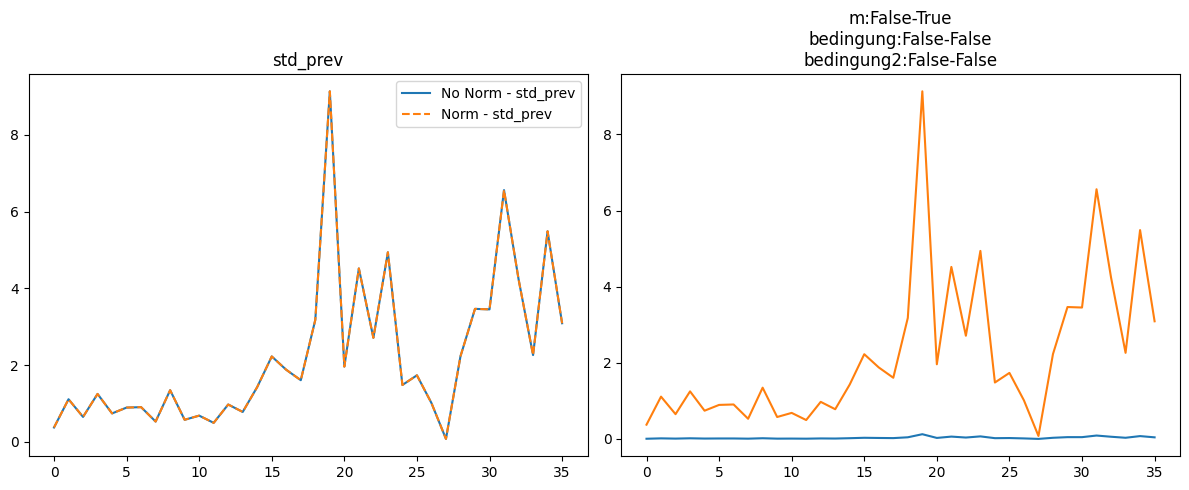

shift: 6.8833827526759706e-15 - factor: 73.52489999999999


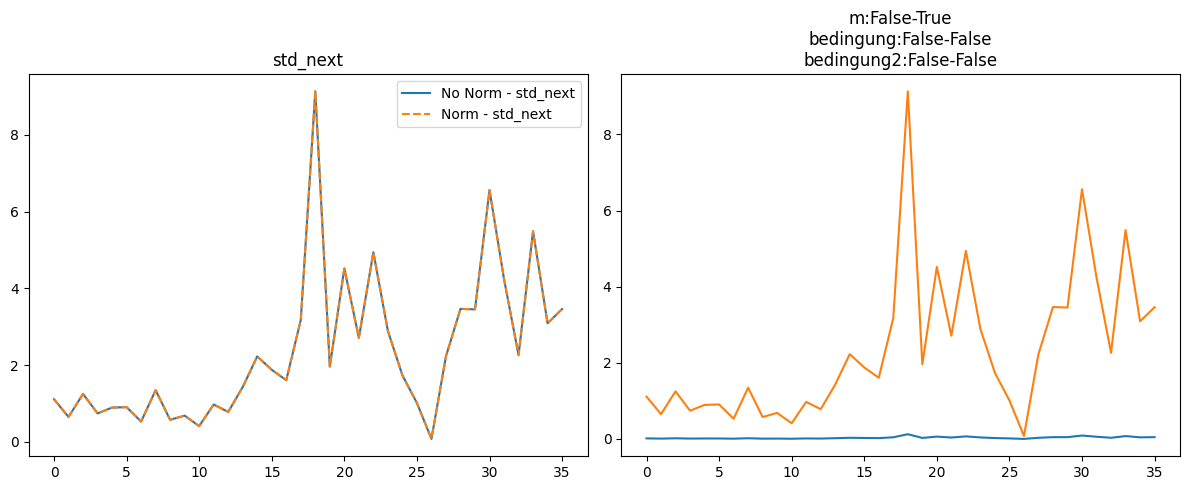

shift: 52.66320000000001 - factor: 73.52489999999999


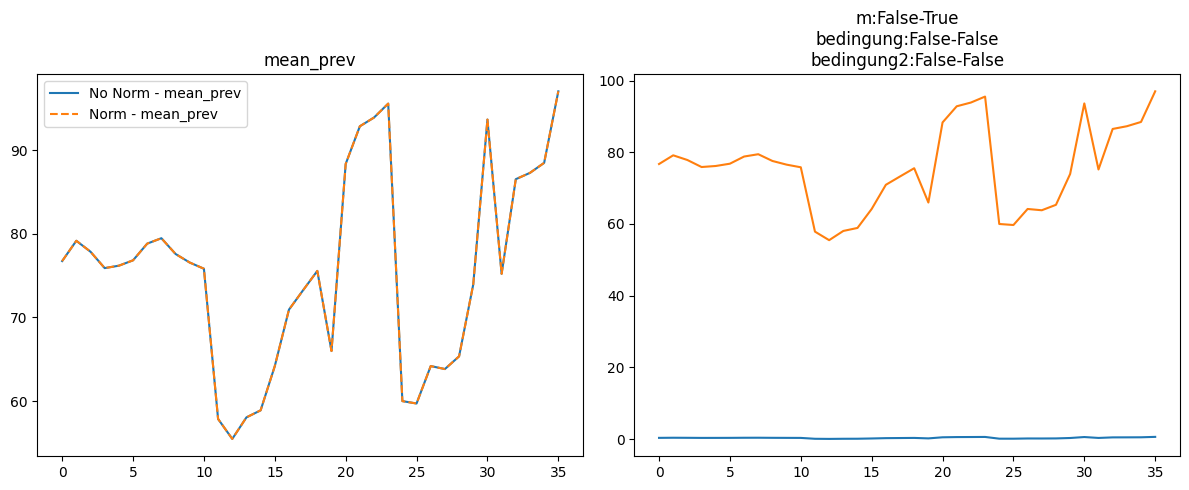

shift: 52.66320000000001 - factor: 73.52490000000002


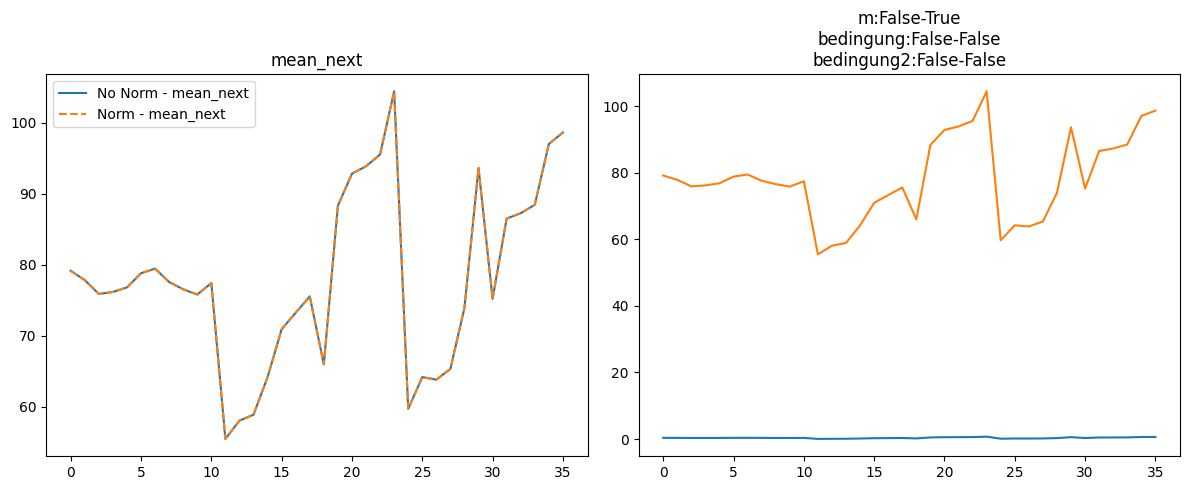

shift: 1.1102230246251565e-15 - factor: 73.52490000000002


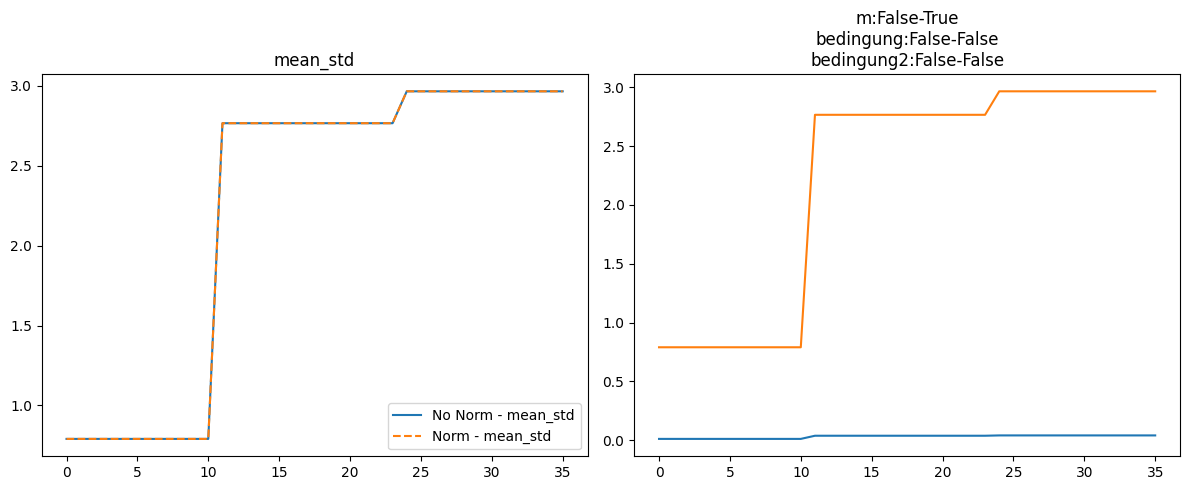

shift: 2.187049119584117e-08 - factor: 73.5249003785117


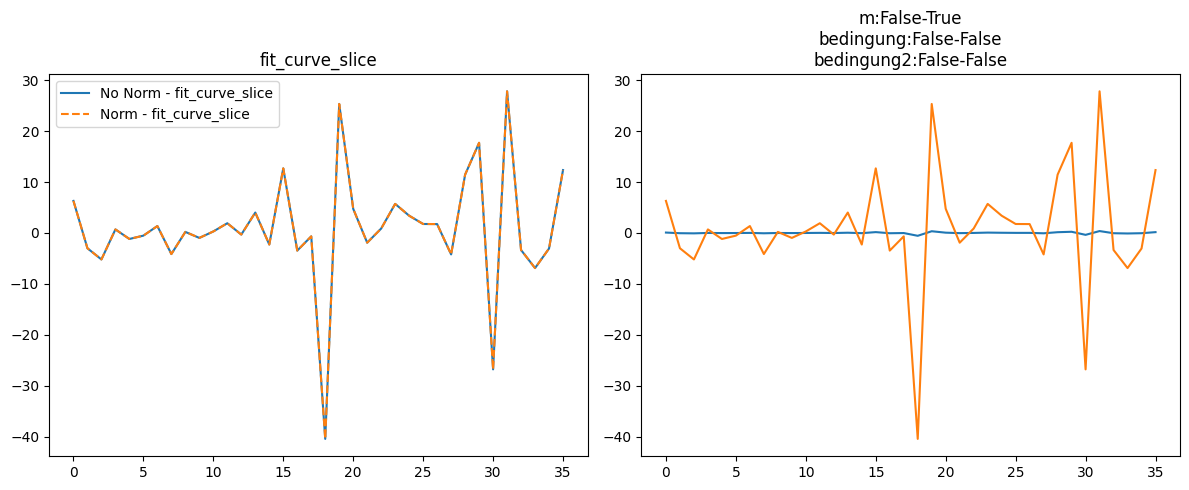

In [14]:
for i in range(len(params)):
    x = df1["Unnamed: 0"]
    y1 = df1[params[i]]
    #y1 = normalize(y1)
    y2 = df2[params[i]]
    y2 = fit_to(y1,y2)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].set_title(params[i])
    ax[0].plot(df1["Unnamed: 0"], y1, label=f'No Norm - {params[i]}')
    ax[0].plot(df2["Unnamed: 0"], y2, label=f'Norm - {params[i]}', linestyle='dashed')
    ax[0].legend()
    
    ax[1].plot(df1["Unnamed: 0"],df2[params[i]],label = "normalized")
    ax[1].set_title(f"m:{df1['m'].iloc[0]}-{df2['m'].iloc[0]}\nbedingung:{df1['bedingung'].iloc[0]}-{df2['bedingung'].iloc[0]}\nbedingung2:{df1['bedingung2'].iloc[0]}-{df2['bedingung2'].iloc[0]}")
    ax[1].plot(df1["Unnamed: 0"],df1[params[i]],label = "unnormalized")
    plt.tight_layout()
    plt.show()

In [15]:
for i in range(len(df1)):
    # ============ m ============
    if False:
        print(f'm: org: {df1["fit_curve_slice"].iloc[i]} < {0.5} {df1["m"].iloc[i]} - norm: {df2["fit_curve_slice"].iloc[i]} < {0.5/73.5} {df2["m"].iloc[i]} - {abs(df2["fit_curve_slice"].iloc[i]) < 0.5/73.5}')
    
    # ============ Bedingung 1 ============
    # Werte aus df1
    std_prev1 = df1.loc[i, 'std_prev']
    std_next1 = df1.loc[i, 'std_next']
    mean_prev1 = df1.loc[i, 'mean_prev']
    mean_next1 = df1.loc[i, 'mean_next']
    mean_std1 = df1.loc[i, 'mean_std']
    cond1 = (std_prev1 < mean_std1*1.2) and (std_next1 < mean_std1*1.1) and ((mean_next1 > mean_prev1*1.05) or (mean_next1 < mean_prev1*0.95))

    # Werte aus df2
    std_prev2 = df2.loc[i, 'std_prev']
    std_next2 = df2.loc[i, 'std_next']
    mean_prev2 = df2.loc[i, 'mean_prev']
    mean_next2 = df2.loc[i, 'mean_next']
    mean_std2 = df2.loc[i, 'mean_std']
    cond2 = (std_prev2 < mean_std2*1.2) and (std_next2 < mean_std2*1.1) and ((mean_next2 > mean_prev2*1.05) or (mean_next2 < mean_prev2*0.95))
    if False:
    
        print(f"Zeile {i}:")
        print(f"df1: std_prev={std_prev1}, std_next={std_next1}, mean_prev={mean_prev1}, mean_next={mean_next1}, mean_std={mean_std1}, Bedingung={cond1}")
        print(f"df2: std_prev={std_prev2}, std_next={std_next2}, mean_prev={mean_prev2}, mean_next={mean_next2}, mean_std={mean_std2}, Bedingung={cond2}")
        if cond1 != cond2:
            print(f"Zeile {i}:")
            print("df1:")
            print(f"  ({std_prev1} < {mean_std1}*1.2) = ({std_prev1} < {mean_std1*1.2}) -> {std_prev1 < mean_std1*1.2}")
            print(f"  ({std_next1} < {mean_std1}*1.1) = ({std_next1} < {mean_std1*1.1}) -> {std_next1 < mean_std1*1.1}")
            print(f"  ({mean_next1} > {mean_prev1}*1.05) = ({mean_next1} > {mean_prev1*1.05}) -> {mean_next1 > mean_prev1*1.05} ratio: {mean_next1/mean_prev1}")
            print(f"  ({mean_next1} < {mean_prev1}*0.95) = ({mean_next1} < {mean_prev1*0.95}) -> {mean_next1 < mean_prev1*0.95}")
            print(f"  Bedingung: {cond1}")
            print("df2:")
            print(f"  ({std_prev2} < {mean_std2}*1.2) = ({std_prev2} < {mean_std2*1.2}) -> {std_prev2 < mean_std2*1.2}")
            print(f"  ({std_next2} < {mean_std2}*1.1) = ({std_next2} < {mean_std2*1.1}) -> {std_next2 < mean_std2*1.1}")
            print(f"  ({mean_next2} > {mean_prev2}*1.05) = ({mean_next2} > {mean_prev2*1.05}) -> {mean_next2 > mean_prev2*1.05} ratio: {mean_next2/mean_prev2} -> {(mean_next2/mean_prev2)/(mean_next1/mean_prev1)}")
            print(f"  ({mean_next2} < {mean_prev2}*0.95) = ({mean_next2} < {mean_prev2*0.95}) -> {mean_next2 < mean_prev2*0.95}")
            print(f"  Bedingung: {cond2}")
            print("-" * 60)
        print("-" * 60)

    # ============ Bedingung 2 ============
    if True:
        
        bedingung2 = (
            (
                abs(df2.loc[i, 'mean_next'] / df2.loc[i, 'mean_prev']) > 2 or
                abs(df2.loc[i, 'mean_next'] / df2.loc[i, 'mean_prev']) < 0.5
            )
        )
        bedingung1 = (
            (
                abs(df1.loc[i, 'mean_next'] / df1.loc[i, 'mean_prev']) > 2 or
                abs(df1.loc[i, 'mean_next'] / df1.loc[i, 'mean_prev']) < 0.5
            )
        )
        # Für df1
        if bedingung1 != bedingung2:
            print("="*50)
        print("df1:")
        print(f"  (abs({mean_next1} / {mean_prev1}) > 2) = ({abs(mean_next1 / mean_prev1)} > 2) -> {abs(mean_next1 / mean_prev1) > 2}")
        print(f"  (abs({mean_next1} / {mean_prev1}) < 0.5) = ({abs(mean_next1 / mean_prev1)} < 0.5) -> {abs(mean_next1 / mean_prev1) < 0.5}")
        print(f"  Bedingung2: (time and ({abs(mean_next1 / mean_prev1) > 2} or {abs(mean_next1 / mean_prev1) < 0.5})) -> {bedingung2}")
        print(f"  Bedingung: {bedingung1}")

        # Für df2
        print("df2:")
        print(f"  (abs({mean_next2} / {mean_prev2}) > 2) = ({abs(mean_next2 / mean_prev2)} > 2) -> {abs(mean_next2 / mean_prev2) > 2}")
        print(f"  (abs({mean_next2} / {mean_prev2}) < 0.5) = ({abs(mean_next2 / mean_prev2)} < 0.5) -> {abs(mean_next2 / mean_prev2) < 0.5}")
        print(f"  Bedingung2: (time and ({abs(mean_next2 / mean_prev2) > 2} or {abs(mean_next2 / mean_prev2) < 0.5})) -> {bedingung2}")  
        print(f"  Bedingung: {bedingung2}")  

df1:
  (abs(79.15653999999999 / 76.72981999999999) > 2) = (1.0316268173182213 > 2) -> False
  (abs(79.15653999999999 / 76.72981999999999) < 0.5) = (1.0316268173182213 < 0.5) -> False
  Bedingung2: (time and (False or False)) -> False
  Bedingung: False
df2:
  (abs(0.3603315339429226 / 0.3273261167305225) > 2) = (1.100833436519129 > 2) -> False
  (abs(0.3603315339429226 / 0.3273261167305225) < 0.5) = (1.100833436519129 < 0.5) -> False
  Bedingung2: (time and (False or False)) -> False
  Bedingung: False
df1:
  (abs(77.84883684210526 / 79.15653999999999) > 2) = (0.9834795310925069 > 2) -> False
  (abs(77.84883684210526 / 79.15653999999999) < 0.5) = (0.9834795310925069 < 0.5) -> False
  Bedingung2: (time and (False or False)) -> False
  Bedingung: False
df2:
  (abs(0.3425456796555352 / 0.3603315339429226) > 2) = (0.9506403059072682 > 2) -> False
  (abs(0.3425456796555352 / 0.3603315339429226) < 0.5) = (0.9506403059072682 < 0.5) -> False
  Bedingung2: (time and (False or False)) -> False
 